# Часть 2. Модели и обучение



In [1]:
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, load_digits
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from dl_layers_part1 import *

ARTIFACT_DIR = "artifacts_numpy_models"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

SEED = 42

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)

set_seed(SEED)
print(f"Seed fixed: {SEED}")
print(f"Artifacts directory: {ARTIFACT_DIR}")

Seed fixed: 42
Artifacts directory: artifacts_numpy_models


### Блок 1. Оптимизация

Чтобы не перегружать ноутбук несколькими вариантами обновления весов, дальше используется только один оптимизатор — `AdamW`. Этого достаточно для всех трёх задач: мультирегрессии, классификации и автоэнкодера.

In [2]:
class AdamW:
    def __init__(self, model, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0):
        self.model = model
        self.lr = lr
        self.base_lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay

        self.params = self._collect(model.getParameters())
        self.grads = self._collect(model.getGradParameters())

        self.mom1 = [np.zeros_like(p) for p in self.params]
        self.mom2 = [np.zeros_like(p) for p in self.params]
        self.step_id = 0

    def _collect(self, nested):
        flat_items = []
        for item in nested:
            if isinstance(item, list):
                flat_items.extend(self._collect(item))
            else:
                flat_items.append(item)
        return flat_items

    def zero_grad(self):
        self.model.zeroGradParameters()

    def set_lr(self, lr):
        self.lr = lr

    def step(self):
        self.step_id += 1

        for idx, (param, grad) in enumerate(zip(self.params, self.grads)):
            if grad is None:
                continue

            if self.weight_decay != 0.0:
                param -= self.lr * self.weight_decay * param

            self.mom1[idx] = self.beta1 * self.mom1[idx] + (1.0 - self.beta1) * grad
            self.mom2[idx] = self.beta2 * self.mom2[idx] + (1.0 - self.beta2) * (grad * grad)

            corr1 = self.mom1[idx] / (1.0 - self.beta1 ** self.step_id)
            corr2 = self.mom2[idx] / (1.0 - self.beta2 ** self.step_id)

            param -= self.lr * corr1 / (np.sqrt(corr2) + self.eps)


def build_optimizer(model, lr=1e-3, weight_decay=0.0, betas=(0.9, 0.999), eps=1e-8):
    return AdamW(
        model=model,
        lr=lr,
        betas=betas,
        eps=eps,
        weight_decay=weight_decay
    )

### Блок 2. Общая тренировочная инфраструктура

В этом разделе собраны переиспользуемые части пайплайна:
- мини-батчи;
- вычисление метрик;
- сохранение параметров;
- train / validation / test циклы;
- warmup;
- scheduler для learning rate;
- early stopping.

In [3]:
def one_hot(y, num_classes):
    y = np.asarray(y).astype(int).ravel()
    out = np.zeros((len(y), num_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out


def iterate_minibatches(X, y=None, batch_size=32, shuffle=True):
    indices = np.arange(len(X))
    if shuffle:
        np.random.shuffle(indices)

    for start_idx in range(0, len(X), batch_size):
        batch_idx = indices[start_idx:start_idx + batch_size]
        if y is None:
            yield X[batch_idx]
        else:
            yield X[batch_idx], y[batch_idx]


def mse_metric(y_pred, y_true):
    return float(np.mean((y_pred - y_true) ** 2))


def mae_metric(y_pred, y_true):
    return float(np.mean(np.abs(y_pred - y_true)))


def rmse_metric(y_pred, y_true):
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def accuracy_metric_from_logits(y_pred, y_true):
    pred_labels = np.argmax(y_pred, axis=1)

    if y_true.ndim == 2:
        true_labels = np.argmax(y_true, axis=1)
    else:
        true_labels = y_true

    return float(np.mean(pred_labels == true_labels))


def make_metric(task, metric_name):
    task = task.lower()
    metric_name = metric_name.lower()

    if task in ["regression", "autoencoder"]:
        mapping = {
            "mse": mse_metric,
            "mae": mae_metric,
            "rmse": rmse_metric,
        }
        if metric_name not in mapping:
            raise ValueError(f"Unknown metric for {task}: {metric_name}")
        return mapping[metric_name]

    if task == "classification":
        if metric_name == "accuracy":
            return accuracy_metric_from_logits
        raise ValueError(f"Unknown metric for classification: {metric_name}")

    raise ValueError(f"Unknown task: {task}")


def make_criterion(task, loss_name):
    task = task.lower()
    loss_name = loss_name.lower()

    if task in ["regression", "autoencoder"] and loss_name == "mse":
        return MSECriterion()

    if task == "classification" and loss_name == "nll":
        return ClassNLLCriterion()

    raise ValueError(f"Unsupported combination: task={task}, loss={loss_name}")


def _flatten_nested(items):
    flat = []
    for item in items:
        if isinstance(item, list):
            flat.extend(_flatten_nested(item))
        else:
            flat.append(item)
    return flat


def copy_parameters(model):
    return [p.copy() for p in _flatten_nested(model.getParameters())]


def load_parameters(model, saved_params):
    current_params = _flatten_nested(model.getParameters())
    for current, saved in zip(current_params, saved_params):
        current[...] = saved


def save_parameters_to_file(model, path):
    params = copy_parameters(model)
    np.savez(path, *params)


def load_parameters_from_file(model, path):
    data = np.load(path)
    params = [data[key] for key in data.files]
    load_parameters(model, params)


def train_epoch(model, criterion, optimizer, X_train, y_train, batch_size=32, metric_fn=None):
    model.train()

    batch_losses = []
    batch_metrics = []

    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size=batch_size, shuffle=True):
        optimizer.zero_grad()

        predictions = model.forward(X_batch)
        loss = criterion.forward(predictions, y_batch)

        grad_loss = criterion.backward(predictions, y_batch)
        model.backward(X_batch, grad_loss)

        optimizer.step()

        batch_losses.append(float(loss))

        if metric_fn is not None:
            batch_metrics.append(metric_fn(predictions, y_batch))

    epoch_loss = float(np.mean(batch_losses))
    epoch_metric = float(np.mean(batch_metrics)) if metric_fn is not None else None

    return epoch_loss, epoch_metric


def evaluate_epoch(model, criterion, X_val, y_val, batch_size=32, metric_fn=None):
    model.evaluate()

    batch_losses = []
    batch_metrics = []

    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size=batch_size, shuffle=False):
        predictions = model.forward(X_batch)
        loss = criterion.forward(predictions, y_batch)

        batch_losses.append(float(loss))

        if metric_fn is not None:
            batch_metrics.append(metric_fn(predictions, y_batch))

    epoch_loss = float(np.mean(batch_losses))
    epoch_metric = float(np.mean(batch_metrics)) if metric_fn is not None else None

    return epoch_loss, epoch_metric


def fit_model(
    model,
    criterion,
    optimizer,
    X_train, y_train,
    X_val=None, y_val=None,
    n_epochs=20,
    batch_size=32,
    metric_fn=None,
    metric_name="metric",
    maximize_metric=False,
    early_stopping_patience=None,
    scheduler_step=None,
    scheduler_gamma=0.1,
    warmup_epochs=0,
    best_model_path=None,
    verbose=True
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_metric": [],
        "val_metric": [],
        "lr": []
    }

    best_state = None
    best_epoch = None
    patience_counter = 0

    if X_val is not None and y_val is not None:
        best_score = -np.inf if maximize_metric and metric_fn is not None else np.inf
    else:
        best_score = None

    for epoch in range(1, n_epochs + 1):
        # разгон learning rate в первые эпохи
        if warmup_epochs > 0 and epoch <= warmup_epochs:
            warmup_lr = optimizer.base_lr * epoch / warmup_epochs
            optimizer.set_lr(warmup_lr)

        train_loss, train_metric = train_epoch(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            X_train=X_train,
            y_train=y_train,
            batch_size=batch_size,
            metric_fn=metric_fn
        )

        history["train_loss"].append(train_loss)
        history["train_metric"].append(train_metric)
        history["lr"].append(float(optimizer.lr))

        if X_val is not None and y_val is not None:
            val_loss, val_metric = evaluate_epoch(
                model=model,
                criterion=criterion,
                X_val=X_val,
                y_val=y_val,
                batch_size=batch_size,
                metric_fn=metric_fn
            )

            history["val_loss"].append(val_loss)
            history["val_metric"].append(val_metric)

            # критерий выбора лучшей точки зависит от выбранной метрики
            if metric_fn is not None:
                current_score = val_metric
                improved = current_score > best_score if maximize_metric else current_score < best_score
            else:
                current_score = val_loss
                improved = current_score < best_score

            if improved:
                best_score = current_score
                best_state = copy_parameters(model)
                best_epoch = epoch
                patience_counter = 0

                if best_model_path is not None:
                    save_parameters_to_file(model, best_model_path)
            else:
                patience_counter += 1

            if verbose:
                print(
                    f"Epoch {epoch:03d} | "
                    f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | "
                    f"train_{metric_name}={train_metric:.6f} | val_{metric_name}={val_metric:.6f} | "
                    f"lr={optimizer.lr:.6f}"
                )
        else:
            if verbose:
                metric_value = float("nan") if train_metric is None else train_metric
                print(
                    f"Epoch {epoch:03d} | "
                    f"train_loss={train_loss:.6f} | "
                    f"train_{metric_name}={metric_value:.6f} | "
                    f"lr={optimizer.lr:.6f}"
                )

        # после warmup применяем план изменения learning rate
        if scheduler_step is not None and epoch > warmup_epochs:
            if epoch % scheduler_step == 0:
                optimizer.set_lr(optimizer.lr * scheduler_gamma)

        # остановка, если улучшений слишком долго нет
        if (
            X_val is not None and y_val is not None and
            early_stopping_patience is not None and
            patience_counter >= early_stopping_patience
        ):
            print(f"Early stopping triggered at epoch {epoch}")
            break

    # в конце поднимаем в память лучшую сохранённую версию
    if best_state is not None:
        load_parameters(model, best_state)

    result = {
        "history": history,
        "best_epoch": best_epoch,
        "best_score": best_score
    }

    return result


def plot_history(history, title, metric_name="metric"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(history["train_loss"], label="train")
    if len(history["val_loss"]) > 0:
        axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()

    if len(history["train_metric"]) > 0 and history["train_metric"][0] is not None:
        axes[1].plot(history["train_metric"], label="train")
        if len(history["val_metric"]) > 0:
            axes[1].plot(history["val_metric"], label="val")
        axes[1].set_title(f"{title}: {metric_name}")
        axes[1].set_xlabel("epoch")
        axes[1].set_ylabel(metric_name)
        axes[1].legend()
    else:
        axes[1].axis("off")

    axes[2].plot(history["lr"], label="lr")
    axes[2].set_title(f"{title}: learning rate")
    axes[2].set_xlabel("epoch")
    axes[2].set_ylabel("lr")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

## Часть A. Мультирегрессия

Для регрессионного примера беру `make_regression` из `sklearn`: датасет офлайн-доступен, легко контролируется по размеру и сразу поддерживает несколько целевых переменных.

In [4]:
# Подготовка синтетической мультирегрессии
X_reg, y_reg = make_regression(
    n_samples=5000,
    n_features=30,
    n_informative=22,
    n_targets=3,
    noise=12.0,
    random_state=SEED
)

X_reg = X_reg.astype(np.float32)
y_reg = y_reg.astype(np.float32)

X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=SEED
)

X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.50, random_state=SEED
)

reg_feature_scaler = StandardScaler()
reg_target_scaler = StandardScaler()

X_train_reg_scaled = reg_feature_scaler.fit_transform(X_train_reg).astype(np.float32)
X_val_reg_scaled = reg_feature_scaler.transform(X_val_reg).astype(np.float32)
X_test_reg_scaled = reg_feature_scaler.transform(X_test_reg).astype(np.float32)

y_train_reg_scaled = reg_target_scaler.fit_transform(y_train_reg).astype(np.float32)
y_val_reg_scaled = reg_target_scaler.transform(y_val_reg).astype(np.float32)
y_test_reg_scaled = reg_target_scaler.transform(y_test_reg).astype(np.float32)

print("Train:", X_train_reg_scaled.shape, y_train_reg_scaled.shape)
print("Val:  ", X_val_reg_scaled.shape, y_val_reg_scaled.shape)
print("Test: ", X_test_reg_scaled.shape, y_test_reg_scaled.shape)

Train: (3500, 30) (3500, 3)
Val:   (750, 30) (750, 3)
Test:  (750, 30) (750, 3)


### FCNN-конфигурации

Собираю одну функцию-конструктор и на её основе запускаю три варианта сети:
- small;
- medium;
- large.

Заодно меняю активации между конфигурациями, чтобы показать сравнение не только по размеру, но и по типу нелинейности.

In [5]:
def build_fcnn(input_dim, output_dim, hidden_dims, activation_cls=ReLU, dropout_p=0.10, bn_alpha=0.9):
    model = Sequential()
    prev_dim = input_dim

    for hidden_dim in hidden_dims:
        model.add(Linear(prev_dim, hidden_dim))
        model.add(BatchNormalization(alpha=bn_alpha))
        model.add(activation_cls())
        model.add(Dropout(p=dropout_p))
        prev_dim = hidden_dim

    model.add(Linear(prev_dim, output_dim))
    return model


regression_experiments = {
    "small_relu": {
        "hidden_dims": [64, 32],
        "activation_cls": ReLU,
        "dropout_p": 0.10
    },
    "medium_gelu": {
        "hidden_dims": [128, 64, 32],
        "activation_cls": Gelu,
        "dropout_p": 0.15
    },
    "large_elu": {
        "hidden_dims": [256, 128, 64, 32],
        "activation_cls": ELU,
        "dropout_p": 0.20
    }
}

REG_LOSS_NAME = "mse"
REG_METRIC_NAME = "mae"

regression_results = {}
regression_models = {}

for exp_name, cfg in regression_experiments.items():
    print("=" * 90)
    print(f"Training regression model: {exp_name}")

    set_seed(SEED)

    model = build_fcnn(
        input_dim=X_train_reg_scaled.shape[1],
        output_dim=y_train_reg_scaled.shape[1],
        hidden_dims=cfg["hidden_dims"],
        activation_cls=cfg["activation_cls"],
        dropout_p=cfg["dropout_p"],
        bn_alpha=0.9
    )

    criterion = make_criterion(task="regression", loss_name=REG_LOSS_NAME)
    metric_fn = make_metric(task="regression", metric_name=REG_METRIC_NAME)

    optimizer = build_optimizer(
        model=model,
        lr=1e-3,
        weight_decay=1e-4
    )

    best_path = os.path.join(ARTIFACT_DIR, f"{exp_name}_best.npz")

    fit_result = fit_model(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        X_train=X_train_reg_scaled,
        y_train=y_train_reg_scaled,
        X_val=X_val_reg_scaled,
        y_val=y_val_reg_scaled,
        n_epochs=40,
        batch_size=64,
        metric_fn=metric_fn,
        metric_name=REG_METRIC_NAME,
        maximize_metric=False,
        early_stopping_patience=8,
        scheduler_step=10,
        scheduler_gamma=0.5,
        warmup_epochs=3,
        best_model_path=best_path,
        verbose=True
    )


    y_test_pred_scaled = model.forward(X_test_reg_scaled)
    y_test_pred = reg_target_scaler.inverse_transform(y_test_pred_scaled)

    test_mse = float(np.mean((y_test_pred - y_test_reg) ** 2))
    test_rmse = float(np.sqrt(test_mse))
    test_mae = float(np.mean(np.abs(y_test_pred - y_test_reg)))

    regression_results[exp_name] = {
        "hidden_dims": cfg["hidden_dims"],
        "activation": cfg["activation_cls"].__name__,
        "dropout": cfg["dropout_p"],
        "best_epoch": fit_result["best_epoch"],
        "best_val_score_scaled": fit_result["best_score"],
        "test_mse_original": test_mse,
        "test_rmse_original": test_rmse,
        "test_mae_original": test_mae,
        "history": fit_result["history"],
        "best_model_path": best_path
    }

    regression_models[exp_name] = model

Training regression model: small_relu
Epoch 001 | train_loss=2.765215 | val_loss=2.092455 | train_mae=0.759508 | val_mae=0.661008 | lr=0.000333
Epoch 002 | train_loss=1.443300 | val_loss=0.676960 | train_mae=0.541861 | val_mae=0.371610 | lr=0.000667
Epoch 003 | train_loss=0.572106 | val_loss=0.247940 | train_mae=0.342361 | val_mae=0.227369 | lr=0.001000
Epoch 004 | train_loss=0.395008 | val_loss=0.164917 | train_mae=0.285045 | val_mae=0.184859 | lr=0.001000
Epoch 005 | train_loss=0.342418 | val_loss=0.127614 | train_mae=0.266319 | val_mae=0.163759 | lr=0.001000
Epoch 006 | train_loss=0.295065 | val_loss=0.098130 | train_mae=0.245544 | val_mae=0.143008 | lr=0.001000
Epoch 007 | train_loss=0.275458 | val_loss=0.085643 | train_mae=0.237687 | val_mae=0.133852 | lr=0.001000
Epoch 008 | train_loss=0.257328 | val_loss=0.071494 | train_mae=0.228078 | val_mae=0.121801 | lr=0.001000
Epoch 009 | train_loss=0.218939 | val_loss=0.065220 | train_mae=0.209217 | val_mae=0.116963 | lr=0.001000
Epoch 01

### Сравнение FCNN-моделей

Ниже свожу результаты трёх сетей и отдельно рисую кривые обучения: loss, metric и динамику learning rate.

In [6]:
regression_summary = pd.DataFrame(regression_results).T[
    [
        "hidden_dims",
        "activation",
        "dropout",
        "best_epoch",
        "best_val_score_scaled",
        "test_mse_original",
        "test_rmse_original",
        "test_mae_original",
        "best_model_path"
    ]
].sort_values("test_mae_original")

display(regression_summary)

best_regression_name = regression_summary.index[0]
best_regression_model = regression_models[best_regression_name]

print(f"Best regression model by test MAE: {best_regression_name}")
print(regression_summary.loc[best_regression_name])

,hidden_dims,activation,dropout,best_epoch,best_val_score_scaled,test_mse_original,test_rmse_original,test_mae_original,best_model_path
small_relu,"[64, 32]",ReLU,0.1,40,0.072466,584.031119,24.166736,19.012613,artifacts_numpy_models\small_relu_best.npz
large_elu,"[256, 128, 64, 32]",ELU,0.2,34,0.068951,1575.467317,39.692157,28.091018,artifacts_numpy_models\large_elu_best.npz
medium_gelu,"[128, 64, 32]",Gelu,0.15,31,0.067505,1355.056629,36.811094,28.130474,artifacts_numpy_models\medium_gelu_best.npz


Best regression model by test MAE: small_relu
hidden_dims                                                [64, 32]
activation                                                     ReLU
dropout                                                         0.1
best_epoch                                                       40
best_val_score_scaled                                      0.072466
test_mse_original                                        584.031119
test_rmse_original                                        24.166736
test_mae_original                                         19.012613
best_model_path          artifacts_numpy_models\small_relu_best.npz
Name: small_relu, dtype: object


### Примеры предсказаний для лучшей регрессионной модели

Кроме итоговой метрики полезно посмотреть несколько пар «истинное значение / прогноз», чтобы увидеть качество по каждому таргету глазами.

In [7]:
best_reg_pred_scaled = best_regression_model.forward(X_test_reg_scaled[:10])
best_reg_pred = reg_target_scaler.inverse_transform(best_reg_pred_scaled)

preview_regression = pd.DataFrame({
    "target_1_true": y_test_reg[:10, 0],
    "target_1_pred": best_reg_pred[:10, 0],
    "target_2_true": y_test_reg[:10, 1],
    "target_2_pred": best_reg_pred[:10, 1],
    "target_3_true": y_test_reg[:10, 2],
    "target_3_pred": best_reg_pred[:10, 2],
})

display(preview_regression.round(3))

,target_1_true,target_1_pred,target_2_true,target_2_pred,target_3_true,target_3_pred
0,58.483002,67.895,46.080002,40.268,103.401001,111.624
1,-131.860001,-155.495,-263.123993,-268.683,-132.979996,-161.918
2,-52.612000,-60.508,21.319000,12.450,-1.193000,9.651
3,-467.588989,-483.174,-347.126007,-309.241,6.638000,-18.290
4,-396.506989,-380.894,-399.683990,-416.591,-382.048004,-380.558
5,309.618011,331.915,287.964996,302.848,257.723999,257.417
6,-266.722992,-247.131,-237.533005,-239.403,-182.309998,-174.627
7,-526.685974,-493.623,-254.046997,-263.031,-223.906998,-207.260
8,-68.169998,-83.330,-86.526001,-66.132,-12.688000,-9.640
9,-139.639008,-137.028,-386.412994,-371.727,-43.838001,-59.969


## Часть B. Мультиклассовая классификация

По условию здесь нужна свёрточная модель с pooling, flatten и softmax-логикой.

Так как все свёртки написаны на NumPy, полный MNIST обучается довольно долго. Поэтому использую уменьшенную подвыборку, а если `torchvision` недоступен, включаю fallback на `sklearn.load_digits`.

In [8]:
def stratified_subsample(X, y, n_samples, seed=42):
    if n_samples is None or n_samples >= len(X):
        return X, y

    splitter = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=seed)
    selected_idx, _ = next(splitter.split(X.reshape(len(X), -1), y))
    return X[selected_idx], y[selected_idx]


def load_digits_dataset(seed=42, train_limit=None, val_limit=None, test_limit=None):
    digits = load_digits()

    X_all = (digits.images / 16.0).astype(np.float32)
    y_all = digits.target.astype(int)

    X_all = X_all[:, None, :, :]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X_all,
        y_all,
        test_size=0.30,
        random_state=seed,
        stratify=y_all
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=seed,
        stratify=y_temp
    )

    X_train, y_train = stratified_subsample(X_train, y_train, train_limit, seed=seed)
    X_val, y_val = stratified_subsample(X_val, y_val, val_limit, seed=seed)
    X_test, y_test = stratified_subsample(X_test, y_test, test_limit, seed=seed)

    return {
        "dataset_name": "sklearn_digits",
        "runtime_profile": "full_dataset" if all(v is None for v in [train_limit, val_limit, test_limit]) else "reduced_subset",
        "X_train": X_train.astype(np.float32),
        "X_val": X_val.astype(np.float32),
        "X_test": X_test.astype(np.float32),
        "y_train_idx": y_train.astype(int),
        "y_val_idx": y_val.astype(int),
        "y_test_idx": y_test.astype(int),
        "y_train": one_hot(y_train, 10),
        "y_val": one_hot(y_val, 10),
        "y_test": one_hot(y_test, 10),
        "input_shape": X_train.shape[1:],
        "num_classes": 10
    }


vision_data = load_digits_dataset(seed=SEED)

print("Dataset used:", vision_data["dataset_name"])
print("Runtime profile:", vision_data["runtime_profile"])
print("Train:", vision_data["X_train"].shape, vision_data["y_train"].shape)
print("Val:  ", vision_data["X_val"].shape, vision_data["y_val"].shape)
print("Test: ", vision_data["X_test"].shape, vision_data["y_test"].shape)

Dataset used: sklearn_digits
Runtime profile: full_dataset
Train: (1257, 1, 8, 8) (1257, 10)
Val:   (270, 1, 8, 8) (270, 10)
Test:  (270, 1, 8, 8) (270, 10)


### Архитектура CNN

Ниже строю компактную сеть из собственных блоков: `Conv2d`, `BatchNormalization`, активаций, pooling, dropout, `Flatten`, `Linear`, `LogSoftMax`.

Размер flatten-части вычисляю программно через dummy-прогон.

In [9]:
def infer_feature_dim(feature_builder, input_shape):
    tmp_model = feature_builder()
    tmp_model.evaluate()

    dummy = np.zeros((2,) + tuple(input_shape), dtype=np.float32)
    out = tmp_model.forward(dummy)

    return out.reshape(out.shape[0], -1).shape[1], out.shape[1:]


def build_cnn_classifier(input_shape=(1, 28, 28), num_classes=10, bn_alpha=0.9):
    def feature_builder():
        model = Sequential()
        model.add(Conv2d(input_shape[0], 4, kernel_size=3, stride=1, padding="same"))
        model.add(BatchNormalization(alpha=bn_alpha))
        model.add(ReLU())
        model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))
        model.add(Dropout(p=0.10))

        model.add(Conv2d(4, 8, kernel_size=3, stride=1, padding="same"))
        model.add(BatchNormalization(alpha=bn_alpha))
        model.add(Gelu())
        model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))
        model.add(Flatten(start_dim=1))
        return model

    flat_dim, feature_shape = infer_feature_dim(feature_builder, input_shape)

    model = feature_builder()
    model.add(Linear(flat_dim, 32))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(ReLU())
    model.add(Dropout(p=0.20))
    model.add(Linear(32, num_classes))
    model.add(LogSoftMax())
    return model, flat_dim, feature_shape


cnn_classifier, cnn_flat_dim, cnn_feature_shape = build_cnn_classifier(
    input_shape=vision_data["input_shape"],
    num_classes=vision_data["num_classes"]
)

print(cnn_classifier)
print("Flatten dimension:", cnn_flat_dim)
print("Feature tensor shape before flatten:", cnn_feature_shape)

Conv2d
BatchNormalization
ReLU
MaxPool2d
Dropout
Conv2d
BatchNormalization
Gelu
MaxPool2d
Flatten
Linear 32 -> 32
BatchNormalization
ReLU
Dropout
Linear 32 -> 10
LogSoftMax

Flatten dimension: 32
Feature tensor shape before flatten: (32,)


### Обучение классификатора

Для этой задачи использую:
- loss: `ClassNLLCriterion`;
- metric: `accuracy`;
- optimizer: `AdamW`.

Тот же тренировочный контур поддерживает warmup, scheduler, early stopping и восстановление лучшей модели.

In [10]:
CLS_LOSS_NAME = "nll"
CLS_METRIC_NAME = "accuracy"
cls_epochs = 20
cls_patience = 6

criterion_cls = make_criterion(task="classification", loss_name=CLS_LOSS_NAME)
metric_fn_cls = make_metric(task="classification", metric_name=CLS_METRIC_NAME)

optimizer_cls = build_optimizer(
    model=cnn_classifier,
    lr=1e-3,
    weight_decay=1e-4
)

cnn_best_path = os.path.join(ARTIFACT_DIR, "cnn_classifier_best.npz")

cnn_fit_result = fit_model(
    model=cnn_classifier,
    criterion=criterion_cls,
    optimizer=optimizer_cls,
    X_train=vision_data["X_train"],
    y_train=vision_data["y_train"],
    X_val=vision_data["X_val"],
    y_val=vision_data["y_val"],
    n_epochs=cls_epochs,
    batch_size=32,
    metric_fn=metric_fn_cls,
    metric_name=CLS_METRIC_NAME,
    maximize_metric=True,
    early_stopping_patience=cls_patience,
    scheduler_step=max(2, cls_epochs // 3),
    scheduler_gamma=0.5,
    warmup_epochs=2,
    best_model_path=cnn_best_path,
    verbose=True
)

test_loss_cls, test_acc_cls = evaluate_epoch(
    model=cnn_classifier,
    criterion=criterion_cls,
    X_val=vision_data["X_test"],
    y_val=vision_data["y_test"],
    batch_size=32,
    metric_fn=metric_fn_cls
)

print(f"Best epoch: {cnn_fit_result['best_epoch']}")
print(f"Test loss:  {test_loss_cls:.6f}")
print(f"Test acc:   {test_acc_cls:.6f}")
print(f"Best model saved to: {cnn_best_path}")

Epoch 001 | train_loss=2.264428 | val_loss=2.163928 | train_accuracy=0.150000 | val_accuracy=0.295635 | lr=0.000500
Epoch 002 | train_loss=1.959171 | val_loss=1.735018 | train_accuracy=0.385764 | val_accuracy=0.668651 | lr=0.001000
Epoch 003 | train_loss=1.685981 | val_loss=1.465191 | train_accuracy=0.536632 | val_accuracy=0.738095 | lr=0.001000
Epoch 004 | train_loss=1.485903 | val_loss=1.281396 | train_accuracy=0.644010 | val_accuracy=0.763393 | lr=0.001000
Epoch 005 | train_loss=1.321101 | val_loss=1.113074 | train_accuracy=0.687847 | val_accuracy=0.802579 | lr=0.001000
Epoch 006 | train_loss=1.162141 | val_loss=0.991920 | train_accuracy=0.747569 | val_accuracy=0.830357 | lr=0.001000
Epoch 007 | train_loss=1.077043 | val_loss=0.928518 | train_accuracy=0.770312 | val_accuracy=0.840774 | lr=0.000500
Epoch 008 | train_loss=1.006226 | val_loss=0.850608 | train_accuracy=0.790104 | val_accuracy=0.837302 | lr=0.000500
Epoch 009 | train_loss=0.961968 | val_loss=0.818361 | train_accuracy=0.7

### Проверка результата на тесте

Помимо accuracy показываю confusion matrix и несколько реальных предсказаний на изображениях из тестовой выборки.

In [11]:
test_log_probs = cnn_classifier.forward(vision_data["X_test"])
test_pred_idx = np.argmax(test_log_probs, axis=1)

cm = confusion_matrix(vision_data["y_test_idx"], test_pred_idx)
cls_report_text = classification_report(vision_data["y_test_idx"], test_pred_idx, digits=4)

print(cls_report_text)

classification_preview = pd.DataFrame({
    "true_label": vision_data["y_test_idx"][:12],
    "pred_label": test_pred_idx[:12]
})

display(classification_preview)

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        27
           1     0.7576    0.8929    0.8197        28
           2     1.0000    0.8846    0.9388        26
           3     0.9000    0.9643    0.9310        28
           4     0.9615    0.9259    0.9434        27
           5     0.9643    1.0000    0.9818        27
           6     0.9630    0.9630    0.9630        27
           7     0.9310    1.0000    0.9643        27
           8     0.7727    0.6538    0.7083        26
           9     0.8400    0.7778    0.8077        27

    accuracy                         0.9074       270
   macro avg     0.9090    0.9062    0.9058       270
weighted avg     0.9086    0.9074    0.9062       270



,true_label,pred_label
0,6,6
1,1,1
2,8,8
3,1,1
4,3,3
5,7,7
6,6,6
7,6,6
8,9,8
9,0,0


## Часть C. Автоэнкодер

Финальный блок — свёрточно-полносвязный автоэнкодер на тех же изображениях.

Энкодер сжимает изображение в латентный вектор, а декодер по нему восстанавливает исходный объект.

In [12]:
def build_conv_autoencoder(input_shape=(1, 28, 28), latent_dim=16, bn_alpha=0.9):
    def encoder_feature_builder():
        model = Sequential()
        model.add(Conv2d(input_shape[0], 4, kernel_size=3, stride=1, padding="same"))
        model.add(BatchNormalization(alpha=bn_alpha))
        model.add(ReLU())
        model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))
        model.add(Dropout(p=0.10))

        model.add(Conv2d(4, 8, kernel_size=3, stride=1, padding="same"))
        model.add(BatchNormalization(alpha=bn_alpha))
        model.add(Gelu())
        model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))
        model.add(Flatten(start_dim=1))
        return model

    flat_dim, feature_shape = infer_feature_dim(encoder_feature_builder, input_shape)

    model = encoder_feature_builder()
    model.add(Linear(flat_dim, 64))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(ReLU())
    model.add(Dropout(p=0.20))

    model.add(Linear(64, latent_dim))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(Gelu())

    model.add(Linear(latent_dim, 64))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(ReLU())
    model.add(Dropout(p=0.10))

    model.add(Linear(64, 128))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(ReLU())

    model.add(Linear(128, int(np.prod(input_shape))))
    return model, flat_dim, feature_shape


autoencoder, ae_flat_dim, ae_feature_shape = build_conv_autoencoder(
    input_shape=vision_data["input_shape"],
    latent_dim=16
)

print(autoencoder)
print("Flatten dimension:", ae_flat_dim)
print("Feature tensor shape before flatten:", ae_feature_shape)

Conv2d
BatchNormalization
ReLU
MaxPool2d
Dropout
Conv2d
BatchNormalization
Gelu
MaxPool2d
Flatten
Linear 32 -> 64
BatchNormalization
ReLU
Dropout
Linear 64 -> 16
BatchNormalization
Gelu
Linear 16 -> 64
BatchNormalization
ReLU
Dropout
Linear 64 -> 128
BatchNormalization
ReLU
Linear 128 -> 64

Flatten dimension: 32
Feature tensor shape before flatten: (32,)


### Обучение автоэнкодера

Здесь вход совпадает с целью. Для оптимизации беру `MSE`, а в качестве дополнительной метрики отслеживаю `MAE`, чтобы смотреть и на абсолютную ошибку реконструкции.

In [13]:
AE_LOSS_NAME = "mse"
AE_METRIC_NAME = "mae"
ae_epochs = 25
ae_patience = 6

X_train_ae_target = vision_data["X_train"].reshape(len(vision_data["X_train"]), -1)
X_val_ae_target = vision_data["X_val"].reshape(len(vision_data["X_val"]), -1)
X_test_ae_target = vision_data["X_test"].reshape(len(vision_data["X_test"]), -1)

criterion_ae = make_criterion(task="autoencoder", loss_name=AE_LOSS_NAME)
metric_fn_ae = make_metric(task="autoencoder", metric_name=AE_METRIC_NAME)

optimizer_ae = build_optimizer(
    model=autoencoder,
    lr=1e-3,
    weight_decay=1e-4
)

ae_best_path = os.path.join(ARTIFACT_DIR, "conv_autoencoder_best.npz")

ae_fit_result = fit_model(
    model=autoencoder,
    criterion=criterion_ae,
    optimizer=optimizer_ae,
    X_train=vision_data["X_train"],
    y_train=X_train_ae_target,
    X_val=vision_data["X_val"],
    y_val=X_val_ae_target,
    n_epochs=ae_epochs,
    batch_size=32,
    metric_fn=metric_fn_ae,
    metric_name=AE_METRIC_NAME,
    maximize_metric=False,
    early_stopping_patience=ae_patience,
    scheduler_step=max(2, ae_epochs // 3),
    scheduler_gamma=0.5,
    warmup_epochs=2,
    best_model_path=ae_best_path,
    verbose=True
)

test_loss_ae, test_mae_ae = evaluate_epoch(
    model=autoencoder,
    criterion=criterion_ae,
    X_val=vision_data["X_test"],
    y_val=X_test_ae_target,
    batch_size=32,
    metric_fn=metric_fn_ae
)

print(f"Best epoch: {ae_fit_result['best_epoch']}")
print(f"Test MSE:   {test_loss_ae:.6f}")
print(f"Test MAE:   {test_mae_ae:.6f}")
print(f"Best model saved to: {ae_best_path}")

Epoch 001 | train_loss=14.637773 | val_loss=6.894438 | train_mae=0.359619 | val_mae=0.247196 | lr=0.000500
Epoch 002 | train_loss=6.331273 | val_loss=4.261372 | train_mae=0.240469 | val_mae=0.193035 | lr=0.001000
Epoch 003 | train_loss=4.829090 | val_loss=3.613068 | train_mae=0.205574 | val_mae=0.173732 | lr=0.001000
Epoch 004 | train_loss=4.101271 | val_loss=3.152124 | train_mae=0.186477 | val_mae=0.158715 | lr=0.001000
Epoch 005 | train_loss=3.730684 | val_loss=2.925365 | train_mae=0.174745 | val_mae=0.150766 | lr=0.001000
Epoch 006 | train_loss=3.519017 | val_loss=2.752193 | train_mae=0.167760 | val_mae=0.143879 | lr=0.001000
Epoch 007 | train_loss=3.294588 | val_loss=2.684583 | train_mae=0.160458 | val_mae=0.142193 | lr=0.001000
Epoch 008 | train_loss=3.151273 | val_loss=2.562885 | train_mae=0.156449 | val_mae=0.137219 | lr=0.001000
Epoch 009 | train_loss=3.056787 | val_loss=2.454061 | train_mae=0.152655 | val_mae=0.133650 | lr=0.000500
Epoch 010 | train_loss=3.008873 | val_loss=2.

### Визуальная проверка реконструкций

Сравниваю оригиналы и восстановленные изображения. Для автоэнкодера это самый наглядный способ оценить, что модель действительно чему-то научилась.

In [14]:
ae_test_recon_flat = autoencoder.forward(vision_data["X_test"])
H, W = vision_data["input_shape"][1], vision_data["input_shape"][2]

ae_test_recon = ae_test_recon_flat.reshape(-1, H, W)
ae_test_true = vision_data["X_test"][:, 0]

latent_dim = 16
compression_ratio = int(np.prod(vision_data["input_shape"])) / latent_dim
print(f"Latent dimension: {latent_dim}")
print(f"Approximate compression ratio: {compression_ratio:.2f}x")

Latent dimension: 16
Approximate compression ratio: 4.00x


## Графики и визуальная диагностика

Ниже все визуализации собраны в одном месте. Явно отделяю численные результаты от графической части, чтобы основной код обучения был компактнее.

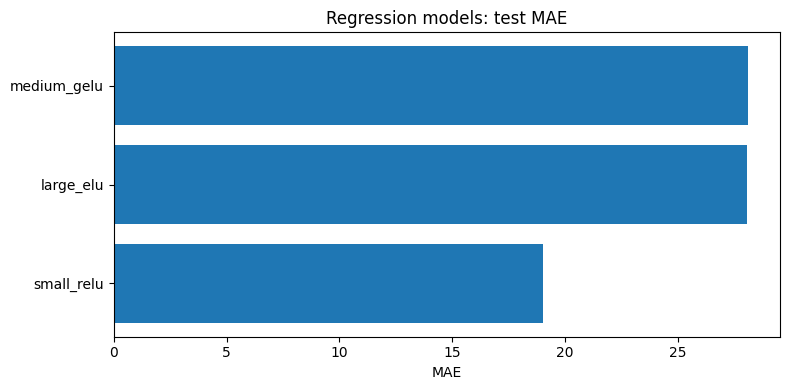

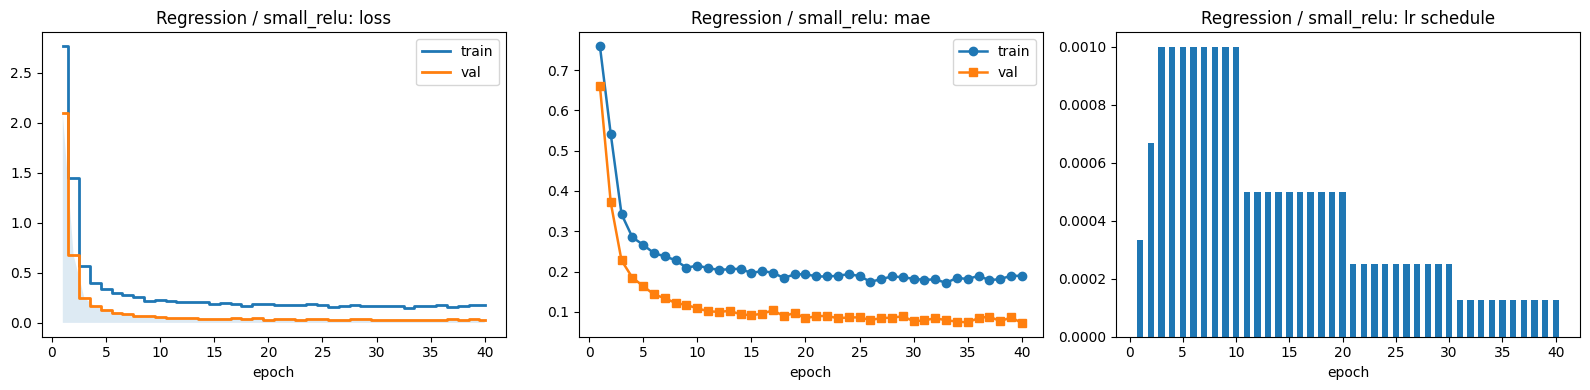

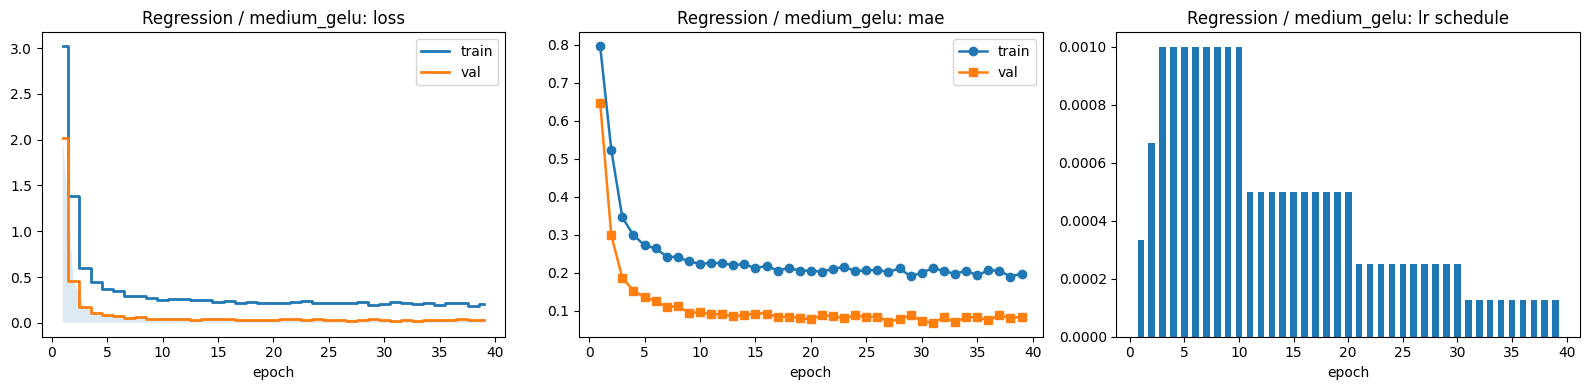

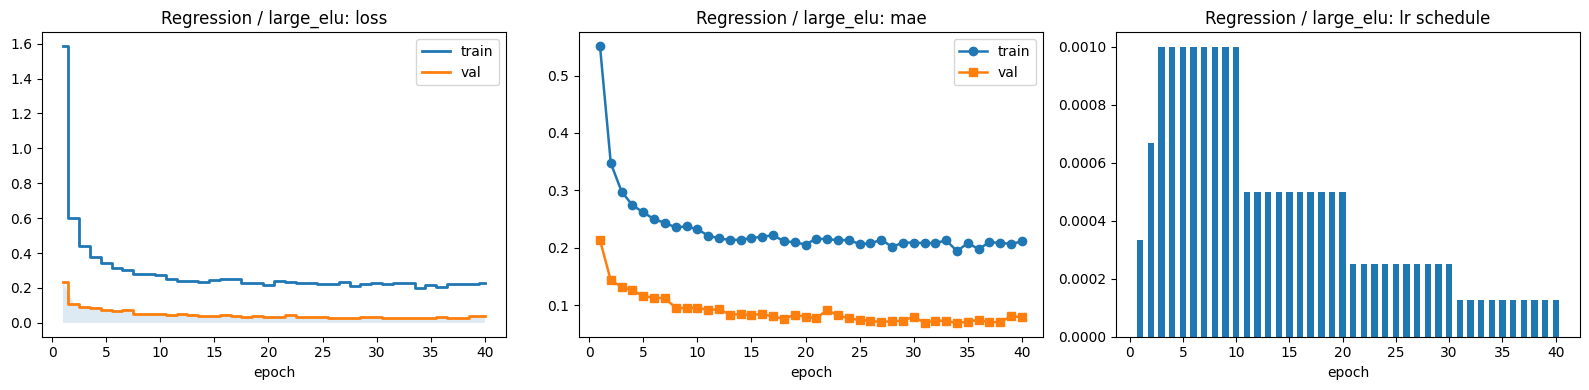

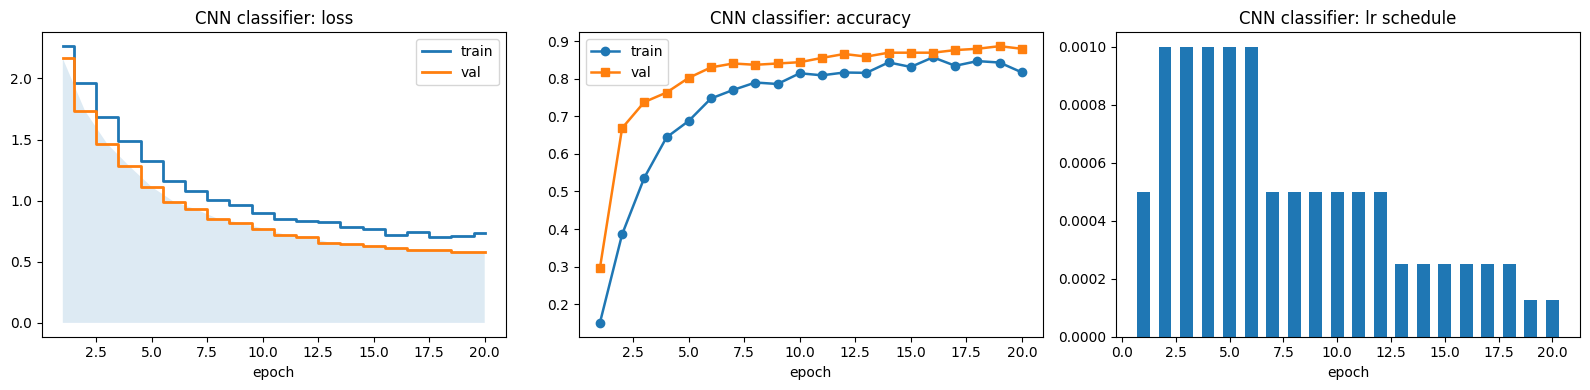

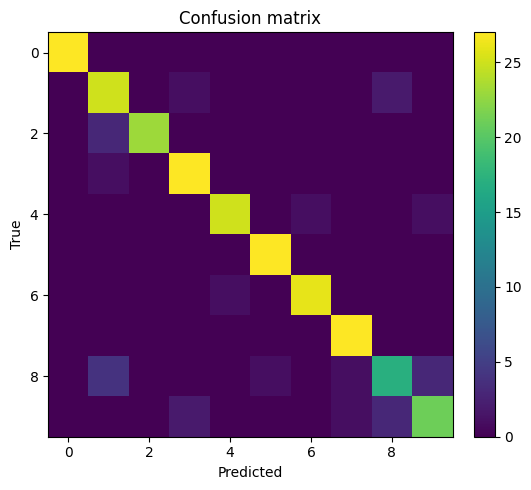

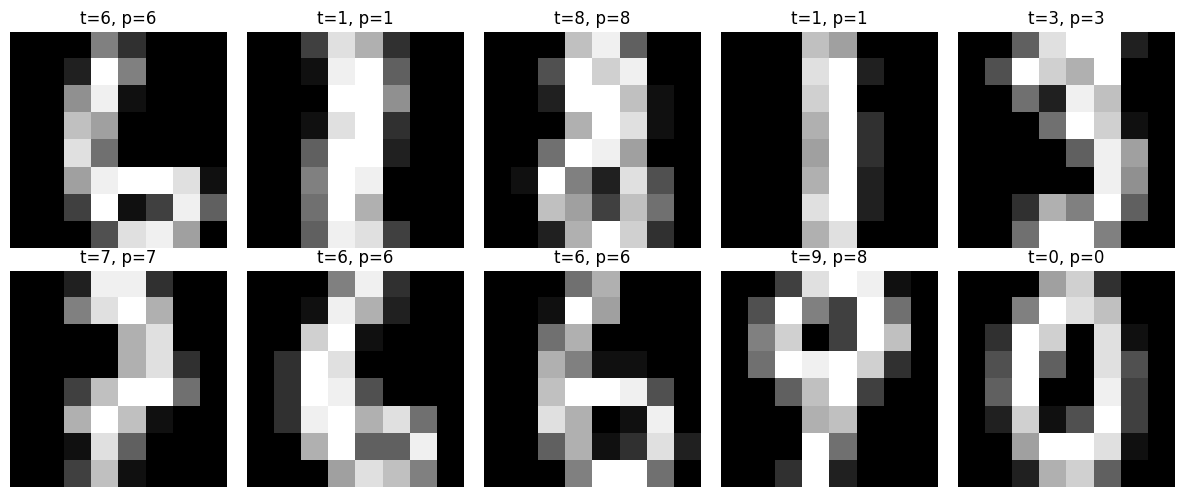

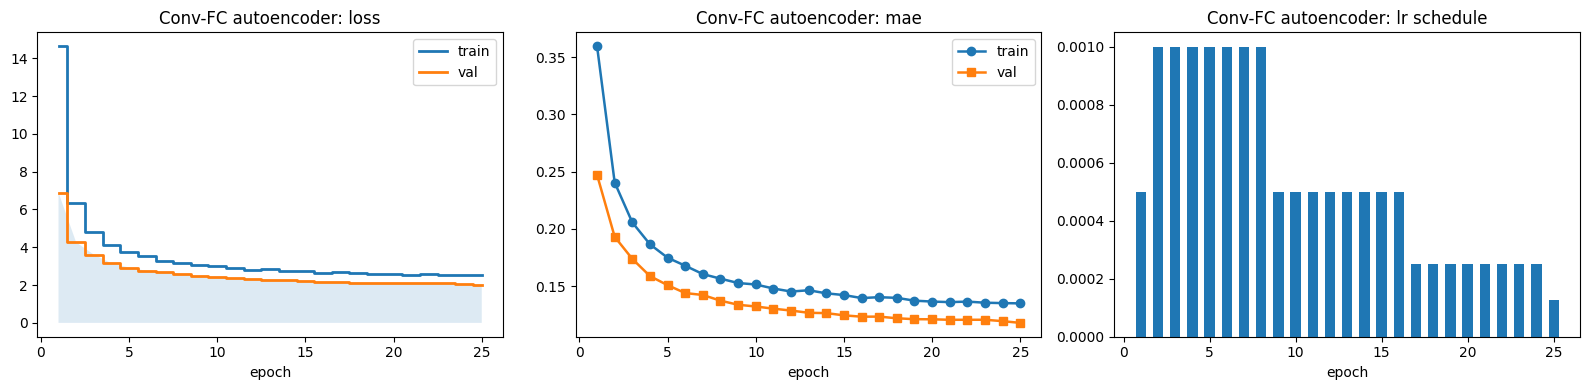

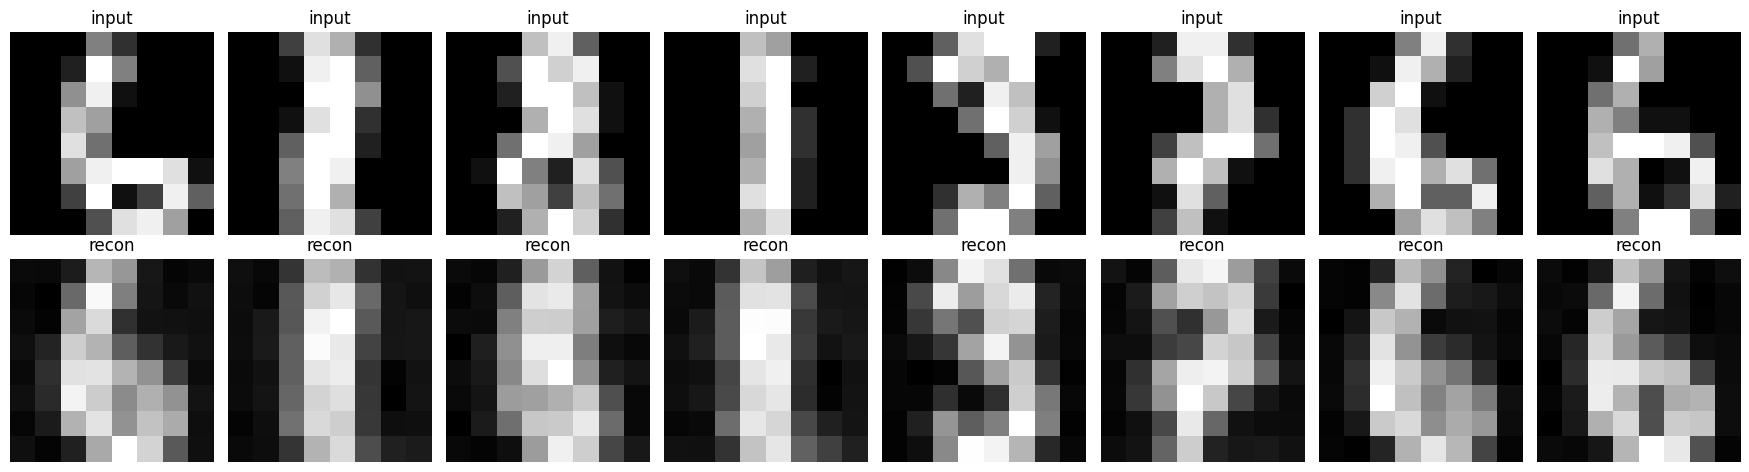

In [15]:
def plot_compact_history(history, title, metric_name):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].step(epochs, history["train_loss"], where="mid", linewidth=2, label="train")
    if len(history["val_loss"]) > 0:
        axes[0].step(epochs[:len(history["val_loss"])], history["val_loss"], where="mid", linewidth=2, label="val")
        axes[0].fill_between(epochs[:len(history["val_loss"])], history["val_loss"], alpha=0.15)
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    if len(history["train_metric"]) > 0 and history["train_metric"][0] is not None:
        axes[1].plot(epochs, history["train_metric"], marker="o", linewidth=1.8, label="train")
        if len(history["val_metric"]) > 0:
            axes[1].plot(epochs[:len(history["val_metric"])], history["val_metric"], marker="s", linewidth=1.8, label="val")
        axes[1].set_title(f"{title}: {metric_name}")
        axes[1].set_xlabel("epoch")
        axes[1].legend()
    else:
        axes[1].axis("off")

    axes[2].bar(epochs, history["lr"], width=0.6)
    axes[2].set_title(f"{title}: lr schedule")
    axes[2].set_xlabel("epoch")

    plt.tight_layout()
    plt.show()


# 1. Сравнение регрессионных моделей по итоговой тестовой ошибке
reg_bar = regression_summary["test_mae_original"].sort_values(ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(reg_bar.index, reg_bar.values)
plt.title("Regression models: test MAE")
plt.xlabel("MAE")
plt.tight_layout()
plt.show()

for exp_name, result in regression_results.items():
    plot_compact_history(result["history"], title=f"Regression / {exp_name}", metric_name=REG_METRIC_NAME)

# 2. Классификация: история обучения и матрица ошибок
plot_compact_history(cnn_fit_result["history"], title="CNN classifier", metric_name=CLS_METRIC_NAME)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

n_show = min(10, len(vision_data["X_test"]))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.ravel(), range(n_show)):
    ax.imshow(vision_data["X_test"][idx, 0], cmap="gray")
    ax.set_title(f"t={vision_data['y_test_idx'][idx]}, p={test_pred_idx[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# 3. Автоэнкодер: история обучения и реконструкции
plot_compact_history(ae_fit_result["history"], title="Conv-FC autoencoder", metric_name=AE_METRIC_NAME)

n_show = min(8, len(ae_test_true))
fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.8))
for i in range(n_show):
    axes[0, i].imshow(ae_test_true[i], cmap="gray")
    axes[0, i].set_title("input")
    axes[0, i].axis("off")

    axes[1, i].imshow(ae_test_recon[i], cmap="gray")
    axes[1, i].set_title("recon")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()